# Step 2 — Exploración del Dataset Crudo

EDA sobre una muestra estratificada (todos los positivos + muestra de negativos).  
**Nunca cargamos las 136M filas en RAM.**

Preguntas que responde este notebook:
1. ¿Cuántos nulos hay por columna?
2. ¿Cómo se distribuyen las features entre fuego vs. no-fuego?
3. ¿Qué estacionalidad tiene el fuego?
4. ¿Hay features con outliers que necesiten truncado?

In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root / 'src'))

from project_config import init_notebook
config = init_notebook()

import utils
logger = utils.init_logger('info')

import warnings
warnings.filterwarnings('ignore')

📂 Project: petenfire2
📁 Root: /Users/mws/Documents/proyectos/AiFire/petenfire2
✅ Config loaded & imports configured


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pyarrow.parquet as pq

TARGET = config['model']['objective_column']
RAW_PATH = Path(config['project_folder']) / config['data']['raw']['local_path'] / 'features.parquet'

NUMERIC_FEATURES = [
    'T2M', 'RH2M', 'WS10M', 'PRECTOTCORR', 'prec_acc7d', 'prec_acc14d',
    'fwi', 'ffmc_val', 'dmc_val', 'dc_val', 'isi_val', 'bui_val',
    'elevation_m', 'slope_deg', 'aspect_deg',
    'dist_roads_km', 'dist_settlements_km',
    'ndvi', 'ndvi_lag7', 'ndvi_lag14',
]

print(f'Target: {TARGET}')

Target: fire_occurred


## 2.1 Muestra estratificada

Todos los positivos (87K) + ~550K negativos aleatorios.

In [3]:
pf = pq.ParquetFile(RAW_PATH)

positives_batches = []
negatives_batches = []
NEG_PER_BATCH = 4000

for batch in pf.iter_batches():
    df_b = batch.to_pandas()
    pos = df_b[df_b[TARGET] == True]
    neg = df_b[df_b[TARGET] == False]
    if len(pos):
        positives_batches.append(pos)
    if len(neg):
        negatives_batches.append(neg.sample(n=min(NEG_PER_BATCH, len(neg)), random_state=42))

positives = pd.concat(positives_batches, ignore_index=True)
negatives = pd.concat(negatives_batches, ignore_index=True)
sample = pd.concat([positives, negatives], ignore_index=True)

print(f'Positivos (todos): {len(positives):,}')
print(f'Negativos (muestra): {len(negatives):,}')
print(f'Total muestra: {len(sample):,}')
print(f'% positivos en muestra: {sample[TARGET].mean()*100:.1f}%')

Positivos (todos): 87,659
Negativos (muestra): 8,308,000
Total muestra: 8,395,659
% positivos en muestra: 1.0%


## 2.2 Nulos por columna

In [4]:
nulls_pct = (sample.isnull().mean() * 100).sort_values(ascending=False)
has_nulls = nulls_pct[nulls_pct > 0]

if len(has_nulls) == 0:
    print('Sin nulos en la muestra.')
else:
    print('Columnas con nulos:')
    for col, pct in has_nulls.items():
        print(f'  {col:<30} {pct:.2f}%')

print(f'\nColumnas sin nulos: {len(nulls_pct[nulls_pct == 0])}')

Columnas con nulos:
  ndvi_lag14                     0.40%
  ndvi_lag7                      0.40%
  ndvi                           0.40%

Columnas sin nulos: 25


## 2.3 Media de features: fuego vs. no-fuego

In [5]:
stats = sample.groupby(TARGET)[NUMERIC_FEATURES].mean().T
stats.columns = ['No fuego', 'Fuego']
stats['Ratio F/NF'] = (stats['Fuego'] / stats['No fuego'].replace(0, np.nan)).round(3)
stats = stats.sort_values('Ratio F/NF', ascending=False)
print(stats.to_string())

                       No fuego       Fuego  Ratio F/NF
fwi                    0.739547    2.909658       3.934
isi_val                1.026872    3.332026       3.245
ffmc_val              52.505586   79.806434       1.520
dmc_val                6.025486    7.180115       1.192
bui_val                5.911063    6.954984       1.177
T2M                   25.465845   29.497703       1.158
WS10M                  1.151412    1.327797       1.153
dc_val                10.050278   10.495773       1.044
aspect_deg           179.943979  180.701855       1.004
slope_deg              6.522380    6.407096       0.982
ndvi_lag14             0.753131    0.669302       0.889
ndvi_lag7              0.753158    0.659728       0.876
ndvi                   0.753373    0.650940       0.864
elevation_m          245.014614  210.588993       0.859
RH2M                  80.324321   60.426211       0.752
dist_settlements_km    6.108578    4.005661       0.656
dist_roads_km          2.641218    1.508874     

## 2.4 Distribuciones: clima y FWI

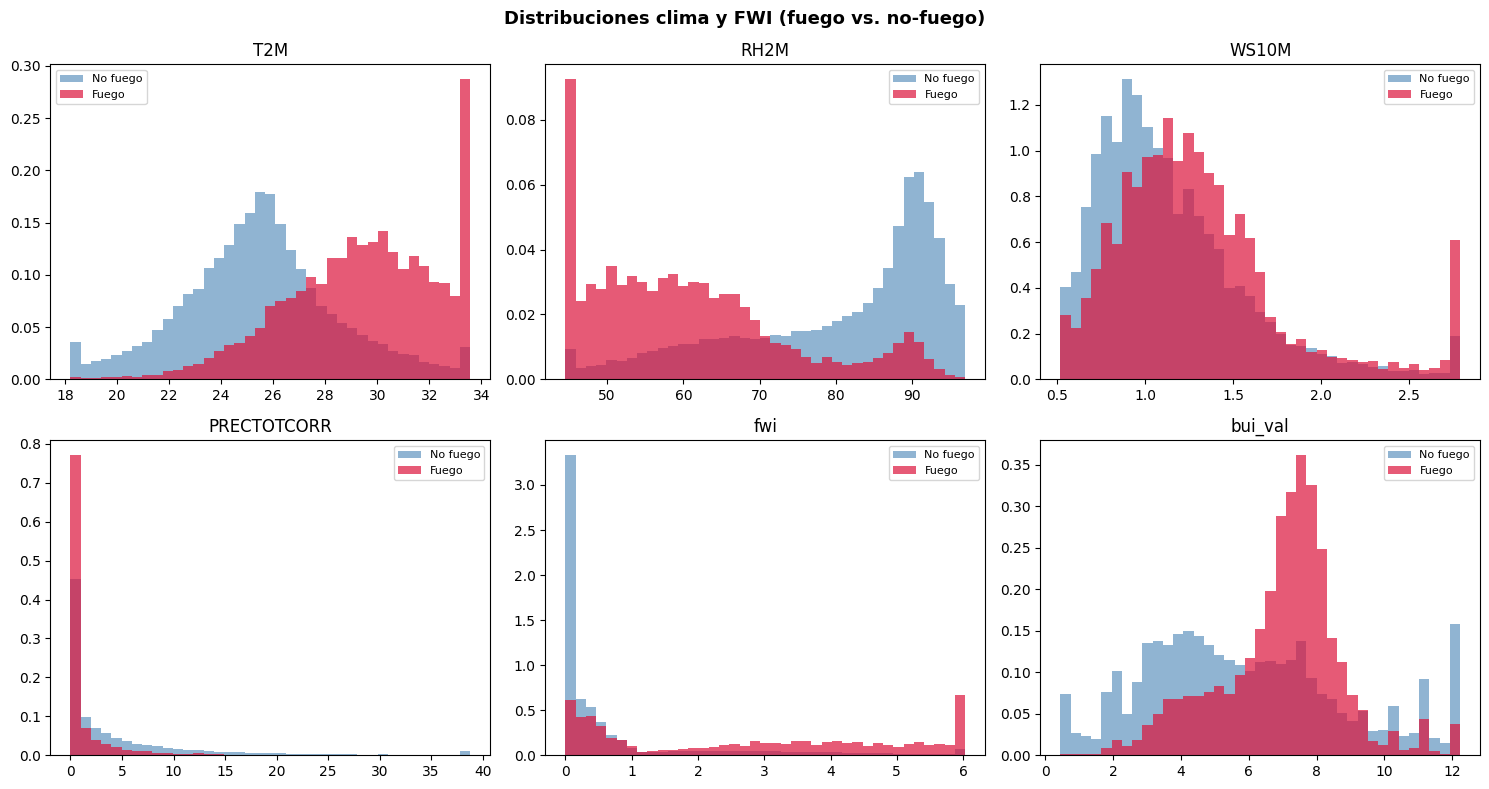

In [6]:
climate_feats = ['T2M', 'RH2M', 'WS10M', 'PRECTOTCORR', 'fwi', 'bui_val']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(climate_feats):
    ax = axes[i]
    no_fire = sample[sample[TARGET] == False][feat].dropna()
    fire    = sample[sample[TARGET] == True][feat].dropna()
    p1  = sample[feat].quantile(0.01)
    p99 = sample[feat].quantile(0.99)
    bins = np.linspace(p1, p99, 40)
    ax.hist(no_fire.clip(p1, p99), bins=bins, alpha=0.6, label='No fuego', density=True, color='steelblue')
    ax.hist(fire.clip(p1, p99),    bins=bins, alpha=0.7, label='Fuego',    density=True, color='crimson')
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones clima y FWI (fuego vs. no-fuego)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.5 Distribuciones: NDVI y estáticas

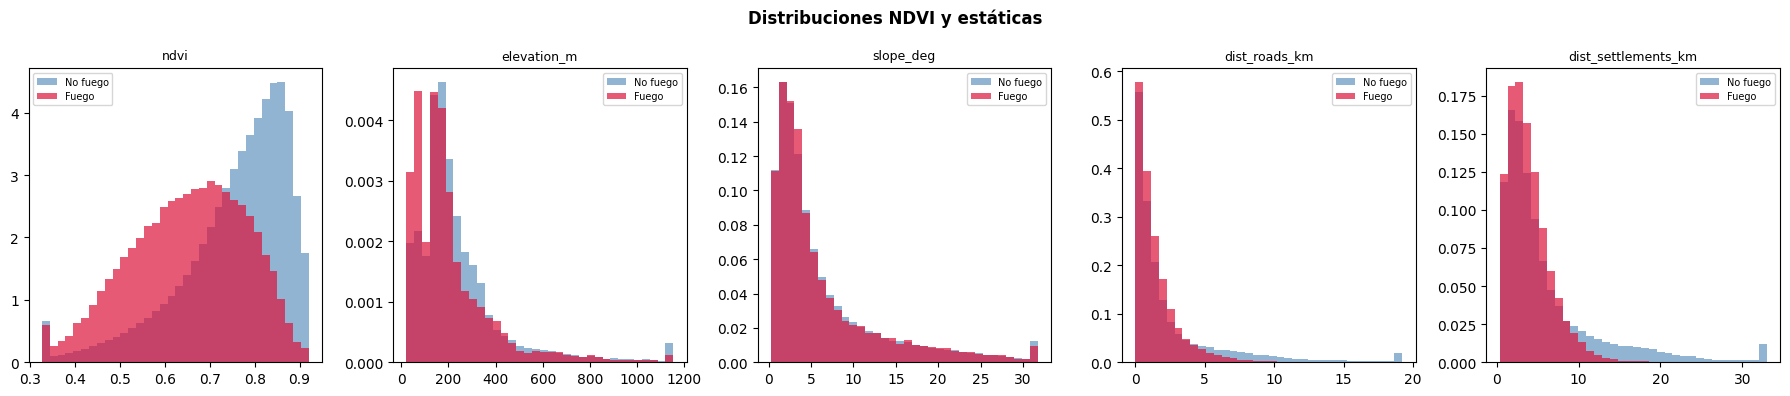

In [7]:
static_feats = ['ndvi', 'elevation_m', 'slope_deg', 'dist_roads_km', 'dist_settlements_km']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, feat in enumerate(static_feats):
    ax = axes[i]
    no_fire = sample[sample[TARGET] == False][feat].dropna()
    fire    = sample[sample[TARGET] == True][feat].dropna()
    p1, p99 = sample[feat].quantile([0.01, 0.99])
    bins = np.linspace(p1, p99, 35)
    ax.hist(no_fire.clip(p1, p99), bins=bins, alpha=0.6, label='No fuego', density=True, color='steelblue')
    ax.hist(fire.clip(p1, p99),    bins=bins, alpha=0.7, label='Fuego',    density=True, color='crimson')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('Distribuciones NDVI y estáticas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.6 Estacionalidad: fuegos por mes

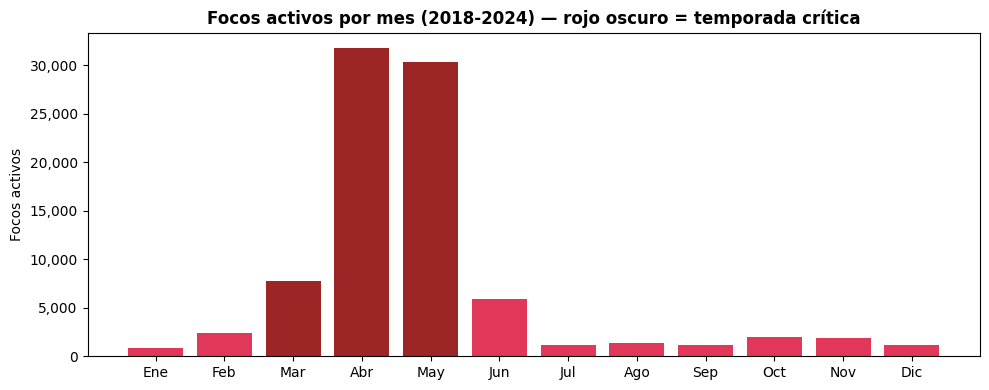

   1:    869 (1.0%)
   2:  2,373 (2.7%)
   3:  7,787 (8.9%)
   4: 31,770 (36.2%)
   5: 30,305 (34.6%)
   6:  5,880 (6.7%)
   7:  1,184 (1.4%)
   8:  1,361 (1.6%)
   9:  1,132 (1.3%)
  10:  1,972 (2.2%)
  11:  1,837 (2.1%)
  12:  1,189 (1.4%)


In [8]:
fires_by_month = positives.groupby('month')[TARGET].sum().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#8B0000' if m in [3, 4, 5] else 'crimson' for m in range(1, 13)]
ax.bar(fires_by_month.index, fires_by_month.values, color=colors, alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_ylabel('Focos activos')
ax.set_title('Focos activos por mes (2018-2024) — rojo oscuro = temporada crítica', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

for m, v in fires_by_month.items():
    print(f'  {m:2d}: {v:6,} ({v/fires_by_month.sum()*100:.1f}%)')

## 2.7 Fuegos por año (train / val / test)

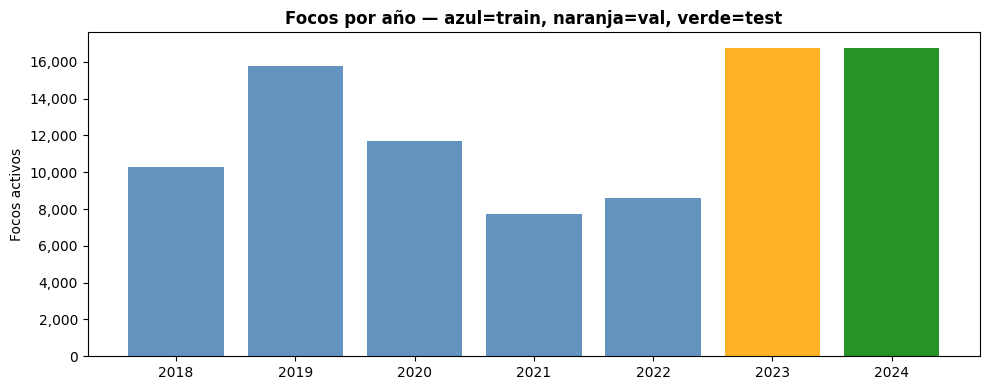

In [9]:
fires_by_year = positives.groupby('year')[TARGET].sum()
colors = ['steelblue' if y <= 2022 else ('orange' if y == 2023 else 'green')
          for y in fires_by_year.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(fires_by_year.index, fires_by_year.values, color=colors, alpha=0.85)
ax.set_ylabel('Focos activos')
ax.set_title('Focos por año — azul=train, naranja=val, verde=test', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 2.8 Correlación con el target

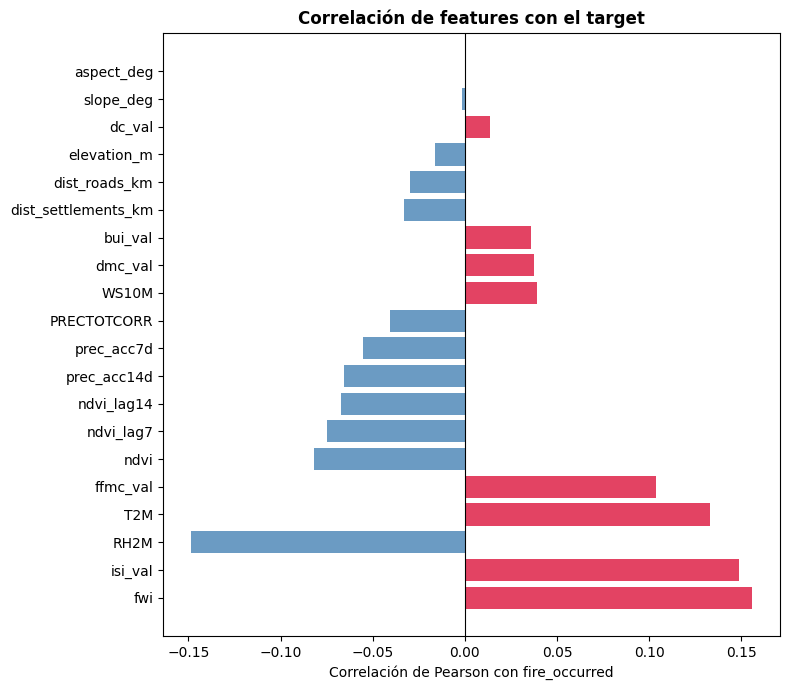

Top 5 correlación positiva:
fwi         0.155817
isi_val     0.148719
RH2M       -0.148501
T2M         0.133318
ffmc_val    0.103483

Top 5 correlación negativa:
dist_roads_km   -0.029693
elevation_m     -0.016201
dc_val           0.013480
slope_deg       -0.001701
aspect_deg       0.000739


In [10]:
sample_num = sample[NUMERIC_FEATURES + [TARGET]].copy()
sample_num[TARGET] = sample_num[TARGET].astype(int)
corr = sample_num.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['crimson' if v > 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con fire_occurred')
ax.set_title('Correlación de features con el target', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 correlación positiva:')
print(corr.head(5).to_string())
print()
print('Top 5 correlación negativa:')
print(corr.tail(5).to_string())

## 2.9 Outliers: ¿qué features necesitan truncado?

In [11]:
desc = sample[NUMERIC_FEATURES].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99])
ratio_p99_max = (desc.loc['99%'] / desc.loc['max'].replace(0, np.nan)).sort_values()

print('Features con mayor diferencia p99 vs max (candidatas a truncate_std):')
for feat, ratio in ratio_p99_max.items():
    max_v = desc.loc['max', feat]
    p99_v = desc.loc['99%', feat]
    flag = ' <-- OUTLIERS' if ratio < 0.5 else ''
    print(f'  {feat:<28} p99={p99_v:>10.2f}  max={max_v:>10.2f}  ratio={ratio:.3f}{flag}')

Features con mayor diferencia p99 vs max (candidatas a truncate_std):
  PRECTOTCORR                  p99=     38.77  max=    227.27  ratio=0.171 <-- OUTLIERS
  prec_acc7d                   p99=    156.03  max=    375.45  ratio=0.416 <-- OUTLIERS
  elevation_m                  p99=   1152.72  max=   2700.52  ratio=0.427 <-- OUTLIERS
  isi_val                      p99=      6.22  max=     12.97  ratio=0.480 <-- OUTLIERS
  fwi                          p99=      6.03  max=     12.17  ratio=0.495 <-- OUTLIERS
  slope_deg                    p99=     31.75  max=     59.65  ratio=0.532
  WS10M                        p99=      2.79  max=      5.17  ratio=0.540
  prec_acc14d                  p99=    247.67  max=    432.60  ratio=0.573
  dist_roads_km                p99=     19.22  max=     33.39  ratio=0.576
  dist_settlements_km          p99=     32.97  max=     44.78  ratio=0.736
  dc_val                       p99=     17.61  max=     20.17  ratio=0.873
  T2M                          p99=     

## 2.10 Resumen para Step 3

In [12]:
print('=== DECISIONES DE PREPROCESAMIENTO ===')
print()
print('NULOS:')
if len(has_nulls):
    for col, pct in has_nulls.items():
        strategy = 'replace_nan=0' if any(k in col for k in ['lag', 'neighbor']) else 'impute=median'
        print(f'  {col:<30} {pct:.2f}% -> {strategy}')
else:
    print('  Sin nulos detectados en muestra. Aplicar impute=median como precaución.')

print()
print('COLUMNAS A DROPEAR en Step 3:')
for col in config['data']['columns_to_drop'] + ['split']:
    print(f'  {col}')

print()
print('BOOLEANAS A CONVERTIR A INT:')
for col in [c for c in sample.columns if sample[c].dtype == bool and c != TARGET]:
    print(f'  {col}')

print()
print('SCALE_POS_WEIGHT para base learners: 1551')
print('UNDER_SAMPLING: 0.10 (config.yaml)')
print('THRESHOLD_STRATEGY: max_recall, min_precision=0.20')
print()
print('Siguiente: step3_preprocess.ipynb')

=== DECISIONES DE PREPROCESAMIENTO ===

NULOS:
  ndvi_lag14                     0.40% -> replace_nan=0
  ndvi_lag7                      0.40% -> replace_nan=0
  ndvi                           0.40% -> impute=median

COLUMNAS A DROPEAR en Step 3:
  date
  cell_id
  split

BOOLEANAS A CONVERTIR A INT:
  is_protected_area

SCALE_POS_WEIGHT para base learners: 1551
UNDER_SAMPLING: 0.10 (config.yaml)
THRESHOLD_STRATEGY: max_recall, min_precision=0.20

Siguiente: step3_preprocess.ipynb
